In [6]:
%load_ext cuml.accel
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
import SimpleITK as sitk
from scipy.ndimage import uniform_filter, binary_closing, binary_dilation, label, center_of_mass

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [2]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [3]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [4]:
no_aug_synth_ds = synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [88]:
def anisotropic_diffusion(img, n_iter = 20, kappa = 0.1, gamma = 0.1):
    sitk_img = sitk.GetImageFromArray(img.numpy().astype(np.float32))
    filt = sitk.GradientAnisotropicDiffusionImageFilter()
    filt.SetNumberOfIterations(n_iter)
    filt.SetConductanceParameter(kappa)
    filt.SetTimeStep(gamma)
    result = filt.Execute(sitk_img)
    return sitk.GetArrayFromImage(result)

def filter_shadow_by_distance(shadow_mask, t_centroid, T_D = 30):
    """
    Step 8: from all connected components in shadow_mask, select the
    largest one whose centroid lies within T_D of the target centroid.
 
    t_centroid : (row, col) tuple from center_of_mass(T_mask)
    T_D        : distance threshold in pixels; paper validates [40, 50]
    """
 
    labeled, n = label(shadow_mask)
    if n == 0:
        return np.zeros_like(shadow_mask)
 
    t_row, t_col = t_centroid
    best_mask = np.zeros_like(shadow_mask)
    best_size = 0
 
    for region_id in range(1, n + 1):
        region = (labeled == region_id)
        c_row, c_col = center_of_mass(region)
        dist = np.sqrt((c_row - t_row) ** 2 + (c_col - t_col) ** 2)
        if dist < T_D:
            
            # if want only the biggest region
            # size = region.sum()
            # if size > best_size:
            #     best_size = size
            #     best_mask = region.astype(int)
            
            # if want all regions
            best_mask |= region
    
    return best_mask

def zhao_segmentation(img):
    I_pm = anisotropic_diffusion(img)
    I_n = readjust_intensity(I_pm)
    T_b, S_b = find_target_and_shadow_mask(I_n, high = 95, low = 22)
    T_c, S_c = counting_filter(T_b, window_size = 5, threshold = 15), counting_filter(S_b, window_size = 5, threshold = 15)
    T_dilated, S_closing = binary_dilation(T_c, structure = structing_ele(shape = 5)).astype(int), binary_dilation(S_c, structure = structing_ele(shape = 5)).astype(int)
    
    T_mask = find_largest_connected_component(T_dilated)
    if T_mask.sum() == 0:
        zeros = np.zeros(image.shape, dtype=int)
        return zeros, zeros, np.ones(image.shape, dtype=int)
    t_centroid = center_of_mass(T_mask)

    S_mask = filter_shadow_by_distance(S_closing, t_centroid)

    clutter = 1 - (T_mask + S_mask)
    return T_mask, S_mask, clutter
    

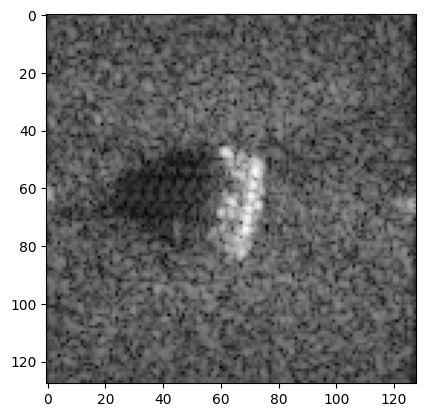

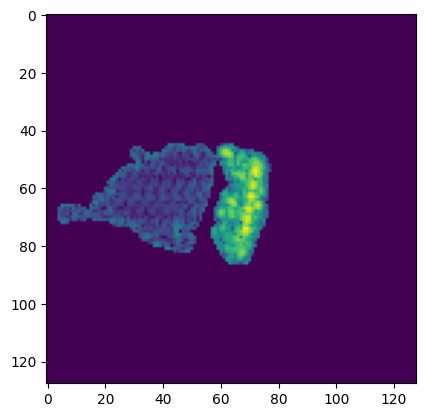

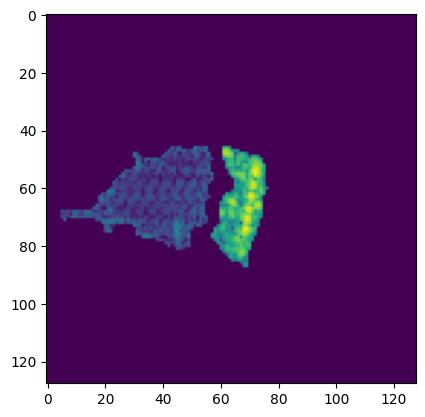

In [92]:
idx = 1344
t, s, c = zhao_segmentation(no_aug_synth_ds[idx][0][0])
plt.imshow(no_aug_synth_ds[idx][0][0], cmap = "grey")
plt.show()
plt.imshow(torch.tensor(t + s) * no_aug_synth_ds[idx][0][0])
plt.show()
t, s,c = choi_segmentation(no_aug_synth_ds[idx][0][0])
plt.imshow(torch.tensor(t + s) * no_aug_synth_ds[idx][0][0])
plt.show()